# Part 1: Fisher Scoring Algorithm

## Imports and helper functions

In [1]:
import pandas as pd
import numpy as np

def add_intercept(X):
    ones = np.ones((X.shape[0], 1))
    return np.hstack([ones, X])

## Load Data (dataset should be in same folder as this script)

In [2]:
# Get data set description
with open('Datasets explanation.txt', 'r') as file:
    doc_text = file.read()
    #print(doc_text)
    
#Load datasets
credit_df = pd.read_csv('CreditCard.csv')
hospital_df = pd.read_csv('Hospital.csv')

### Transform hospital data

In [3]:
y_hospital = hospital_df['los'].values.astype(float)

# Choose features (dropping 'died' due to endogeneity concerns)
hospital_num = hospital_df[['age']].copy()  # continuous
hospital_cat = hospital_df[['procedure', 'gender', 'type']].copy()  # binary

x_num = hospital_num.astype(float).values

# standardize continous only
num_mean = x_num.mean(axis=0)
num_std = x_num.std(axis=0, ddof=0)
num_std = np.where(num_std == 0, 1, num_std)  # avoid divide-by-zero
x_num_std = (x_num - num_mean) / num_std

# dummies for categorical (keep as 0/1, no standardization)
x_cat = pd.get_dummies(hospital_cat, drop_first=True).values.astype(int)

# combine
x_hospital = np.column_stack([x_num_std, x_cat])

# add intercept
x_hospital = add_intercept(x_hospital)



### Transform credit data

In [4]:
y_credit = credit_df["card"].astype(str).str.strip().str.lower().map({"no":0, "yes":1}).to_numpy()

# Choose features (dropping share and expenditure to avoid collinearity with income)
credit_num = credit_df[['reports', 'age', 'income', 'dependents', 'months', 'active']].copy()  # continuous
credit_cat = credit_df[['owner', 'selfemp', 'majorcards']].copy()  # binary

x_num = credit_num.astype(float).values

# standardize continous only
num_mean = x_num.mean(axis=0)
num_std = x_num.std(axis=0, ddof=0)
num_std = np.where(num_std == 0, 1, num_std)  # avoid divide-by-zero
x_num_std = (x_num - num_mean) / num_std

# dummies for categorical (keep as 0/1, no standardization)
x_cat = pd.get_dummies(credit_cat, drop_first=True).values.astype(int)

# combine
x_credit = np.column_stack([x_num_std, x_cat])

# add intercept
x_credit = add_intercept(x_credit)

## Fisher Algorithm 
### ...with differentiation between Poisson and Logistics regression

In [5]:
import numpy as np
def fisher_glm(
    X,
    y,
    use_logistic=True,   # True -> logistic; False -> Poisson
    tol=1e-6,
    max_iter=100):

    beta = np.zeros(X.shape[1], dtype=float) #initialize beta

    for _ in range(max_iter):
        eta = X @ beta

        if use_logistic:
            # Logistic mean and weights
            mu = 1.0 / (1.0 + np.exp(-eta))
            mu = np.clip(mu, 1e-9, 1 - 1e-9)
            W = mu * (1.0 - mu)
        else:
            # Poisson mean and weights (clip eta for stability)
            eta_clipped = np.clip(eta, -20, 20)
            mu = np.exp(eta_clipped)
            W = mu

        # Score and expected information
        score = X.T @ (y - mu)
        WX = X * W[:, np.newaxis]
        information = X.T @ WX

        # Solve for step
        step = np.linalg.solve(information, score)

        beta_new = beta + step

        if np.linalg.norm(beta_new - beta) < tol: 
            beta = beta_new
            return beta, True #algo converged --> return True

        beta = beta_new
    return beta, False #did not converge --> return False

## Result Analysis
### Hospital (Poisson Regression)

In [6]:
coef_names = ['intercept', 'age', 'procedure', 'gender', 'type']
coefs, convergence = fisher_glm(x_hospital, y_hospital, use_logistic = False)

print(f'{'Converged' if convergence else 'Did not converge'}')
print(f'Estimated coefficients: \n')

for i in range(len(coef_names)):
    print(f' {coef_names[i]:12s}:  {np.round(coefs[i],3)}.')

Converged
Estimated coefficients: 

 intercept   :  1.284.
 age         :  0.041.
 procedure   :  1.122.
 gender      :  -0.103.
 type        :  0.19.


### CreditCard (Logistic Regression)

In [7]:
coef_names = ['intercept','reports', 'age', 'income', 'dependents', 'months', 'active', 'majorcards', 'owner', 'selfemp']

coefs, convergence = fisher_glm(x_credit, y_credit)

print(f'{'Converged' if convergence else 'Did not converge'}')
print(f'Estimated coefficients: \n')

for i in range(len(coef_names)):
    print(f' {coef_names[i]:12s}:  {np.round(coefs[i],3)}.')

Converged
Estimated coefficients: 

 intercept   :  0.887.
 reports     :  -2.356.
 age         :  -0.127.
 income      :  0.383.
 dependents  :  -0.302.
 months      :  0.034.
 active      :  0.834.
 majorcards  :  0.505.
 owner       :  0.478.
 selfemp     :  -0.757.


## Comparison with built-in function 
### Hospital (Poisson Regression)

In [8]:
import statsmodels.api as sm
coef_names = ['intercept', 'age', 'procedure', 'gender', 'type']

poisson_res = sm.GLM(
    y_hospital,
    x_hospital,
    family=sm.families.Poisson()).fit()

for i in range(len(coef_names)):
    print(f' {coef_names[i]:12s}:  {np.round(poisson_res.params[i],3)}.')

 intercept   :  1.284.
 age         :  0.041.
 procedure   :  1.122.
 gender      :  -0.103.
 type        :  0.19.


### CreditCard (Logistic Regression)

In [9]:
from sklearn.linear_model import LogisticRegression
coef_names = ['intercept','reports', 'age', 'income', 'dependents', 'months', 'active', 'majorcards', 'owner', 'selfemp']

clf = LogisticRegression(penalty="l2", C= 1000000000, fit_intercept=False, max_iter=100)
clf.fit(x_credit, y_credit)

for i in range(len(coef_names)):
    print(f' {coef_names[i]:12s}:  {np.round(clf.coef_[0,i],3)}.')

 intercept   :  0.887.
 reports     :  -2.354.
 age         :  -0.127.
 income      :  0.384.
 dependents  :  -0.302.
 months      :  0.035.
 active      :  0.833.
 majorcards  :  0.506.
 owner       :  0.475.
 selfemp     :  -0.754.


## McFadden pseudo R^2 

In [10]:
from scipy.special import gammaln

def mcfadden_pseudo_r2(X, y, beta_hat, use_logistic=True, eps=1e-12):
    X = np.asarray(X, float)
    y = np.asarray(y, float).reshape(-1)
    beta_hat = np.asarray(beta_hat, float).reshape(-1)

    eta = X @ beta_hat

    if use_logistic:
        p = 1.0 / (1.0 + np.exp(-eta))
        p = np.clip(p, eps, 1 - eps)
        ll_full = np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))

        p0 = np.clip(np.mean(y), eps, 1 - eps)
        ll_null = np.sum(y * np.log(p0) + (1 - y) * np.log(1 - p0))

    else:
        mu = np.exp(eta)
        mu = np.clip(mu, eps, None)
        ll_full = np.sum(y * np.log(mu) - mu - gammaln(y + 1))

        mu0 = np.clip(np.mean(y), eps, None)
        ll_null = np.sum(y * np.log(mu0) - mu0 - gammaln(y + 1))

    return 1.0 - (ll_full / ll_null)


# CreditCard (logistic)
beta_credit, conv_credit = fisher_glm(x_credit, y_credit, use_logistic=True)
r2_credit = mcfadden_pseudo_r2(x_credit, y_credit, beta_credit, use_logistic=True)
print("McFadden pseudo-R^2 (Credit / Logistic):", r2_credit)

# Hospital (poisson)
beta_hosp, conv_hosp = fisher_glm(x_hospital, y_hospital, use_logistic=False)
r2_hosp = mcfadden_pseudo_r2(x_hospital, y_hospital, beta_hosp, use_logistic=False)
print("McFadden pseudo-R^2 (Hospital / Poisson):", r2_hosp)

McFadden pseudo-R^2 (Credit / Logistic): 0.302042176340767
McFadden pseudo-R^2 (Hospital / Poisson): 0.28040708143979565


## P-value calculation (Wald)

In [11]:
from scipy.stats import norm

def wald_pvalues_from_fisher(X, beta_hat, use_logistic=True, ridge=0.0):
    
    X = np.asarray(X, float)
    beta_hat = np.asarray(beta_hat, float).reshape(-1)

    eta = X @ beta_hat

    if use_logistic:
        p = 1.0 / (1.0 + np.exp(-eta))
        W = p * (1.0 - p)
    else:
        mu = np.exp(eta)
        W = mu

    WX = X * W[:, None]
    info = X.T @ WX

    if ridge > 0:
        info = info + ridge * np.eye(info.shape[0])

    cov = np.linalg.pinv(info)  # pinv is robust if nearly singular
    se = np.sqrt(np.clip(np.diag(cov), 0, np.inf))

    z = beta_hat / se
    pvals = 2.0 * norm.sf(np.abs(z))

    return se, z, pvals

# Credit (logistic)
beta_credit, conv_credit = fisher_glm(x_credit, y_credit, use_logistic=True)
se_c, z_c, p_c = wald_pvalues_from_fisher(x_credit, beta_credit, use_logistic=True)
coef_names = ['intercept','reports', 'age', 'income', 'dependents', 'months', 'majorcards', 'active', 'owner', 'selfemp']
print('creditcard dataset')
for i in range(len(coef_names)):
    print(f' {coef_names[i]:12s}:  {np.round(p_c[i],5)}.')
    
# Hospital (poisson)
beta_hosp, conv_hosp = fisher_glm(x_hospital, y_hospital, use_logistic=False)
se_h, z_h, p_h = wald_pvalues_from_fisher(x_hospital, beta_hosp, use_logistic=False)
coef_names = ['intercept', 'age', 'procedure', 'gender', 'type']
print('hospital dataset:')
for i in range(len(coef_names)):
    print(f' {coef_names[i]:12s}:  {np.round(p_h[i],10)}.')

creditcard dataset
 intercept   :  0.0.
 reports     :  0.0.
 age         :  0.19214.
 income      :  0.00043.
 dependents  :  0.00046.
 months      :  0.71418.
 majorcards  :  0.0.
 active      :  0.00808.
 owner       :  0.01689.
 selfemp     :  0.00879.
hospital dataset:
 intercept   :  0.0.
 age         :  8.96e-07.
 procedure   :  0.0.
 gender      :  1.57e-08.
 type        :  0.0.


# Part 2: MCMC 

In [12]:
import matplotlib.pyplot as plt

def acf(x, max_lag=50):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    c = np.correlate(x, x, mode="full")[len(x)-1:]
    c /= c[0] if c[0] != 0 else 1.0
    return c[:max_lag+1]


def trace_and_acf(chain, idx, name, max_lag=50):
    s = chain[:, idx]
    fig, ax = plt.subplots(2, 1, figsize=(10, 6), tight_layout=True)
    
    # Trace
    ax[0].plot(s)
    ax[0].set_title(f"Trace")
    ax[0].set_xlabel("iteration")

    # acf
    a = acf(s, max_lag=max_lag)
    ax[1].stem(range(max_lag + 1), a) 
    ax[1].set_title(f"ACF: {name}")
    ax[1].set_xlabel("lag")
    plt.show()

def summarize_chain(chain, names):
    mean = chain.mean(axis=0)
    lower = np.quantile(chain, 0.025, axis=0)
    upper = np.quantile(chain, 0.975, axis=0)
    return pd.DataFrame({"mean": mean, "q2.5": lower, "q97.5": upper}, index=names)


def mh_rw(logpost, init, step, seed, n_iter=60000, burn=12000, adapt_every=500, target=0.50):
    rng = np.random.default_rng(seed)
    beta = np.array(init, float)
    d = beta.size

    chain = np.empty((n_iter, d))
    logp_beta = float(logpost(beta))

    accepted = 0
    accepted_win = 0

    for t in range(n_iter):
        beta_prop = beta + step * rng.standard_normal(d)
        logp_prop = float(logpost(beta_prop))

        if np.log(rng.random()) < min(0.0, logp_prop - logp_beta):
            beta, logp_beta = beta_prop, logp_prop
            accepted += 1
            accepted_win += 1

        chain[t] = beta

        if t < burn and (t + 1) % adapt_every == 0:
            acc_w = accepted_win / adapt_every
            if acc_w < target:
                step *= 0.9
            else:
                step *= 1.1
            accepted_win = 0

    return chain[burn:], accepted / n_iter, step


def logpost_logistic(beta, X, y, prior_sd=5.0):
    eta = X @ beta
    ll = np.sum(y * eta - np.logaddexp(0.0, eta))  
    lp = -0.5 * np.sum((beta / prior_sd) ** 2)         
    return float(ll + lp)

def logpost_poisson(beta, X, y, prior_sd=5.0):
    eta = X @ beta
    ll = np.sum(y * eta - np.exp(np.clip(eta, -700, 700))) 
    lp = -0.5 * np.sum((beta / prior_sd) ** 2)
    return float(ll + lp)

## Result Analysis - CreditCard (Logistic)

Logistic Acceptance: 0.458 Step: 0.04854805195199543


,mean,q2.5,q97.5
intercept,0.901969,0.549306,1.290641
reports,-2.400048,-2.783445,-2.034576
age,-0.127974,-0.316692,0.053734
income,0.389092,0.182379,0.619456
dependents,-0.304251,-0.476481,-0.131880
months,0.039596,-0.135999,0.227852
active,0.848926,0.619354,1.078314
majorcards,0.499825,0.115602,0.854365
owner,0.482650,0.066139,0.899974
selfemp,-0.725883,-1.290000,-0.132820


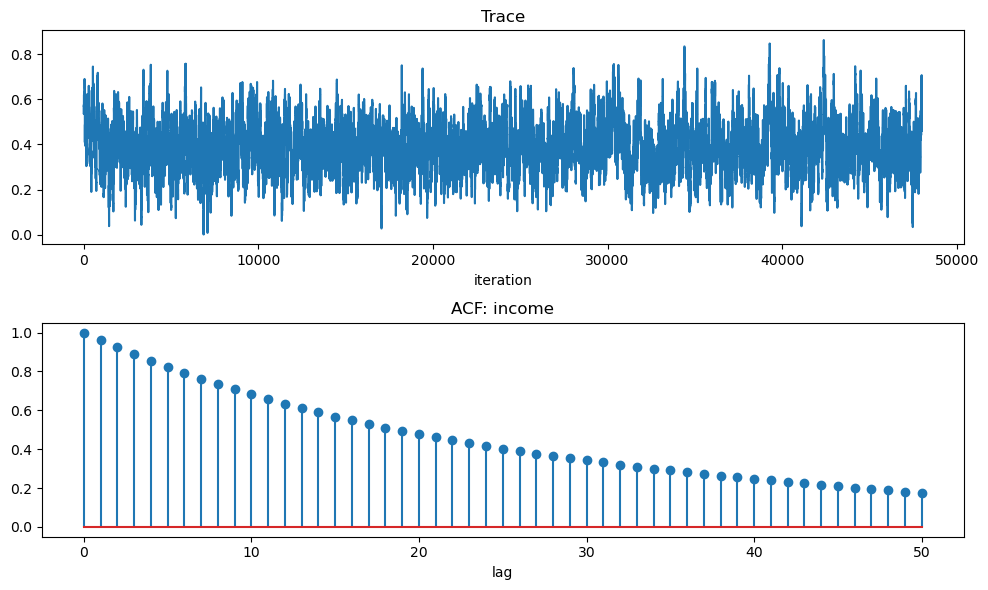

In [13]:


names_credit = ['intercept','reports', 'age', 'income', 'dependents', 'months', 'active', 'majorcards', 'owner', 'selfemp']
income_idx = names_credit.index("income")

beta0 = np.zeros(x_credit.shape[1])

chain_log, acc_log, step_final = mh_rw(
    lambda b: logpost_logistic(b, x_credit, y_credit),
    beta0,
    step=0.1,
    seed=0
)


print("Logistic Acceptance:", round(acc_log, 3), "Step:", step_final)
display(summarize_chain(chain_log, names_credit))

trace_and_acf(chain_log, income_idx, "income")

## Result Analysis - Hospital data (Poisson)

Poisson acceptance: 0.436 Step: 0.007120015199442109


,mean,q2.5,q97.5
intercept,1.284884,1.242397,1.329292
age,0.041156,0.024648,0.057503
procedure,1.120961,1.083349,1.157525
gender,-0.102855,-0.136066,-0.068035
type,0.189846,0.156933,0.221681


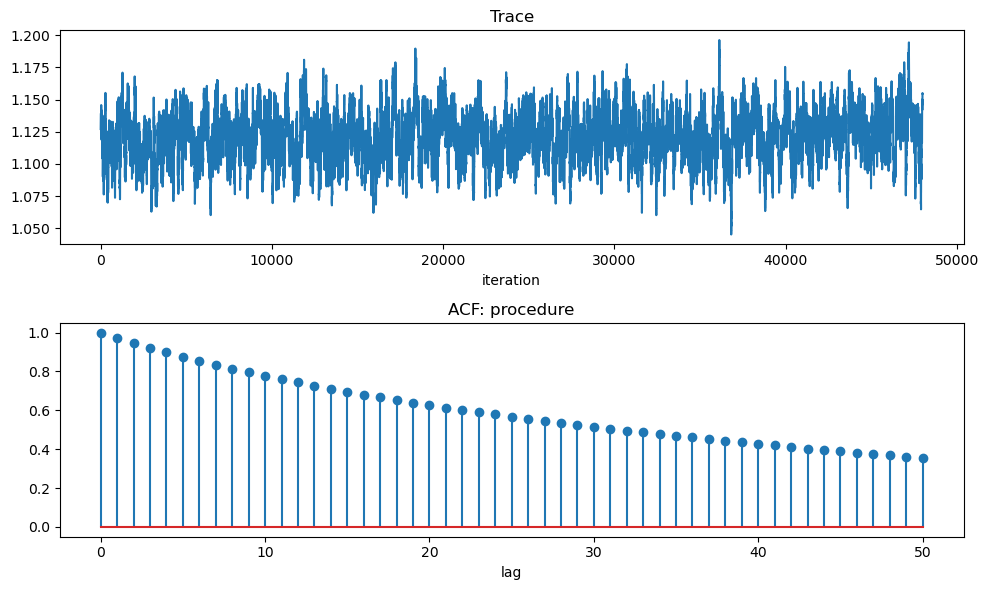

In [14]:


names_az = ['intercept', 'age', 'procedure', 'gender', 'type']
procedure_idx = names_az.index("procedure")

beta0_az = np.zeros(x_hospital.shape[1])

chain_pois, acc_pois, step_final = mh_rw(
    lambda b: logpost_poisson(b, x_hospital, y_hospital),
    beta0_az,
    step=0.04,   
    seed=1,
)

print("Poisson acceptance:", round(acc_pois, 3), "Step:", step_final)
display(summarize_chain(chain_pois, names_az))

trace_and_acf(chain_pois, procedure_idx, "procedure")


## R^2 for MCMC

In [33]:
# Logistic (credit)
beta_bar_credit = chain_log.mean(axis=0)
print("Credit McFadden (beta_bar):", mcfadden_pseudo_r2(x_credit, y_credit, beta_bar_credit, use_logistic=True))

# Poisson (AZ)
beta_bar_az = chain_pois.mean(axis=0)
print("AZ McFadden (beta_bar):", mcfadden_pseudo_r2(x_hospital, y_hospital, beta_bar_az, use_logistic=False))

Credit McFadden (beta_bar): 0.30196894045330935
AZ McFadden (beta_bar): 0.28040690288406833
